--- Starting Income vs. Consumption Analysis (Dual Language Output) ---
Total consumers in Itapuã: 15,297
Sectors with valid consumption data: 102
Final Sectors for Analysis: 99


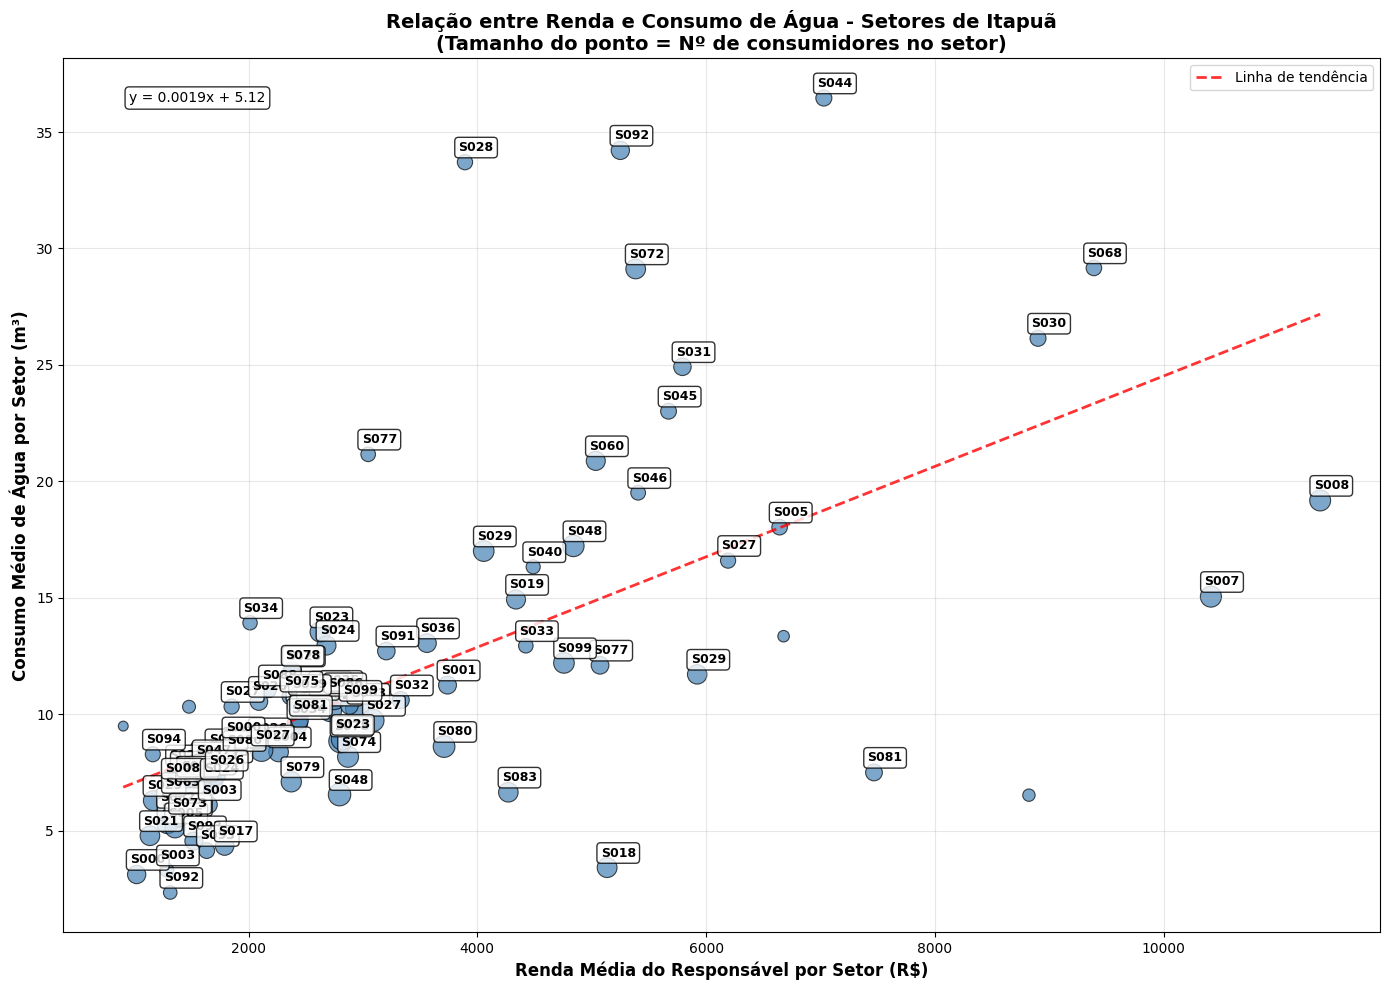

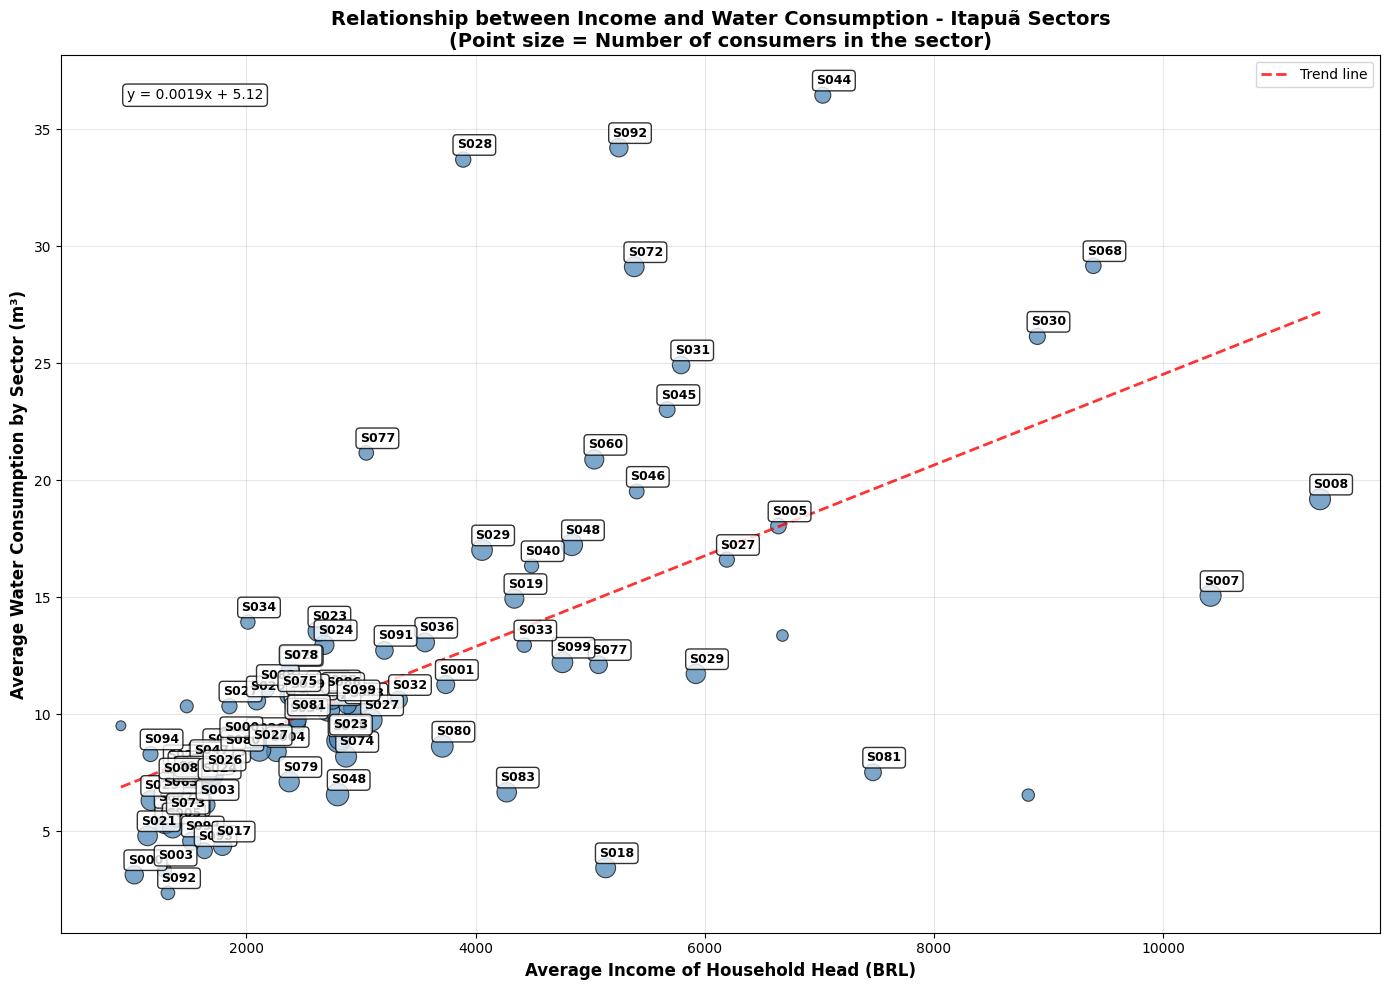

STATISTICAL ANALYSIS - INCOME vs CONSUMPTION
Mean Income (RENDA): R$ 3187.53
Mean Consumption (CONSUMO): 11.31 m³
Pearson Correlation: 0.626

Data saved to: E:\Projetos\ABMS-WP\resultados\resultado_analise_consumo_x_renda_itapua.csv
PT Plot saved to: E:\Projetos\ABMS-WP\figuras\grafico_resultado_analise_consumo_x_renda_itapua_pt.png
EN Plot saved to: E:\Projetos\ABMS-WP\figuras\grafico_resultado_analise_consumo_x_renda_itapua_en.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 1. Configuration and Style
# ==========================================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Base Paths (Uncomment the active path)
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

def convert_sector_id_short(full_sector_id):
    """
    Converts the long Sector ID format to short format (SXXX).
    Example: 1234567890 -> S790
    """
    sector_str = str(full_sector_id)
    return 'S' + sector_str[7] + sector_str[-2:]

def clean_income_value(value):
    """
    Converts income string values to float, handling 'X' as NaN.
    """
    if isinstance(value, str):
        if value.strip().upper() == 'X':
            return np.nan
        # Format cleaning: remove thousands separator, fix decimal
        value = value.replace('.', '').replace(',', '.')
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

def main():
    print("--- Starting Income vs. Consumption Analysis (Dual Language Output) ---")

    # ==========================================
    # 2. Load Consumer Data
    # ==========================================
    # Load original consumer data
    consumers_path = os.path.join(BASE_PATH, 'includes', 'Tabela_consumidores_Itapua_com_setor.csv')
    consumers_df = pd.read_csv(consumers_path, sep=',')
    
    print(f"Total consumers in Itapuã: {len(consumers_df):,}")
    
    # ==========================================
    # 3. Load and Calculate Average Consumption
    # ==========================================
    consumption_history_path = os.path.join(BASE_PATH, 'includes', 'Tabela_consumo_Itapua_60m.csv')
    consumption_history_df = pd.read_csv(consumption_history_path, sep=';')
    
    # Process dates and sort
    consumption_history_df['AM_REFERENCIA'] = pd.to_datetime(consumption_history_df['AM_REFERENCIA'], format='%Y%m')
    consumption_history_df = consumption_history_df.sort_values(by=['SK_MATRICULA', 'AM_REFERENCIA'], ascending=[True, False])
    
    # Get last 12 months average
    last_12_months = consumption_history_df.groupby('SK_MATRICULA').head(12)
    avg_consumption = last_12_months.groupby('SK_MATRICULA')['HCLQTCON'].mean().reset_index()
    
    # Rename using PORTUGUESE column name
    avg_consumption.rename(columns={'HCLQTCON': 'NN_MEDIA_CONSUMO'}, inplace=True)
    
    # Merge average consumption into main consumer dataframe
    consumers_df = pd.merge(consumers_df, avg_consumption, on='SK_MATRICULA', how='left')
    
    # ==========================================
    # 4. Aggregate Consumption by Sector
    # ==========================================
    consumers_df['CD_SETOR'] = consumers_df['CD_SETOR'].astype(str)
    
    # Aggregating using Portuguese column names
    sector_consumption = consumers_df.groupby('CD_SETOR').agg({
        'NN_MEDIA_CONSUMO': 'mean',
        'SK_MATRICULA': 'count'
    }).reset_index()
    
    # Renaming to specific Portuguese keys for internal logic
    sector_consumption = sector_consumption.rename(columns={
        'NN_MEDIA_CONSUMO': 'CONSUMO_MEDIO_SETOR',
        'SK_MATRICULA': 'QTD_CONSUMIDORES'
    })
    
    # Filter valid sectors
    sector_consumption = sector_consumption[sector_consumption['CONSUMO_MEDIO_SETOR'].notna()]
    sector_consumption = sector_consumption[sector_consumption['CONSUMO_MEDIO_SETOR'] > 0]
    
    print(f"Sectors with valid consumption data: {len(sector_consumption)}")
    
    # ==========================================
    # 5. Load Income Data
    # ==========================================
    income_path = os.path.join(BASE_PATH, 'includes', 'ibge_censo2022','Agregados_por_setores_renda_responsavel_BR.csv')
    income_df = pd.read_csv(income_path, sep=';')
    
    income_df['CD_SETOR'] = income_df['CD_SETOR'].astype(str)
    
    # Rename to Portuguese key
    income_df = income_df.rename(columns={'V06004': 'RENDA_MEDIA_RESPONSAVEL'})
    income_df['RENDA_MEDIA_RESPONSAVEL'] = income_df['RENDA_MEDIA_RESPONSAVEL'].apply(clean_income_value)
    
    # ==========================================
    # 6. Merge Consumption and Income Data
    # ==========================================
    sector_analysis = pd.merge(
        sector_consumption,
        income_df[['CD_SETOR', 'RENDA_MEDIA_RESPONSAVEL']],
        on='CD_SETOR',
        how='inner'
    )
    
    sector_analysis = sector_analysis.dropna(subset=['RENDA_MEDIA_RESPONSAVEL'])
    
    # Create Short Sector ID (SXXX)
    sector_analysis['CD_SETOR_SXXX'] = sector_analysis['CD_SETOR'].apply(convert_sector_id_short)
    
    # Filter extreme outliers (< 50m3)
    sector_analysis = sector_analysis[sector_analysis['CONSUMO_MEDIO_SETOR'] < 50]
    
    print(f"Final Sectors for Analysis: {len(sector_analysis)}")

    # ==========================================
    # 7. Generate Plots
    # ==========================================
    
    # --- PLOT 1: PORTUGUESE VERSION ---
    plt.figure(figsize=(14, 10))
    
    plt.scatter(
        sector_analysis['RENDA_MEDIA_RESPONSAVEL'],
        sector_analysis['CONSUMO_MEDIO_SETOR'],
        s=sector_analysis['QTD_CONSUMIDORES'] * 0.8 + 50,
        alpha=0.7,
        c='steelblue',
        edgecolors='black',
        linewidth=0.8
    )
    
    # Labels
    for i, row in sector_analysis.iterrows():
        if row['QTD_CONSUMIDORES'] > 50:
            plt.annotate(f"{row['CD_SETOR_SXXX']}", 
                         (row['RENDA_MEDIA_RESPONSAVEL'], row['CONSUMO_MEDIO_SETOR']),
                         xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), ha='center')
    
    # Text in Portuguese
    plt.xlabel('Renda Média do Responsável por Setor (R$)', fontsize=12, fontweight='bold')
    plt.ylabel('Consumo Médio de Água por Setor (m³)', fontsize=12, fontweight='bold')
    plt.title('Relação entre Renda e Consumo de Água - Setores de Itapuã\n(Tamanho do ponto = Nº de consumidores no setor)', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Trend line (PT)
    if len(sector_analysis) > 1:
        z = np.polyfit(sector_analysis['RENDA_MEDIA_RESPONSAVEL'], sector_analysis['CONSUMO_MEDIO_SETOR'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sector_analysis['RENDA_MEDIA_RESPONSAVEL'].min(), sector_analysis['RENDA_MEDIA_RESPONSAVEL'].max(), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2, label='Linha de tendência')
        equation = f"y = {z[0]:.4f}x + {z[1]:.2f}"
        plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        plt.legend()
    
    plt.tight_layout()
    plot_path_pt = os.path.join(BASE_PATH, 'figuras', 'grafico_resultado_analise_consumo_x_renda_itapua_pt.png')
    plt.savefig(plot_path_pt, dpi=300, bbox_inches='tight')
    plt.show() # Display PT plot
    
    # --- PLOT 2: ENGLISH VERSION ---
    plt.figure(figsize=(14, 10)) # New Figure
    
    plt.scatter(
        sector_analysis['RENDA_MEDIA_RESPONSAVEL'],
        sector_analysis['CONSUMO_MEDIO_SETOR'],
        s=sector_analysis['QTD_CONSUMIDORES'] * 0.8 + 50,
        alpha=0.7,
        c='steelblue',
        edgecolors='black',
        linewidth=0.8
    )
    
    # Labels
    for i, row in sector_analysis.iterrows():
        if row['QTD_CONSUMIDORES'] > 50:
            plt.annotate(f"{row['CD_SETOR_SXXX']}", 
                         (row['RENDA_MEDIA_RESPONSAVEL'], row['CONSUMO_MEDIO_SETOR']),
                         xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), ha='center')
    
    # Text in English
    plt.xlabel('Average Income of Household Head (BRL)', fontsize=12, fontweight='bold')
    plt.ylabel('Average Water Consumption by Sector (m³)', fontsize=12, fontweight='bold')
    plt.title('Relationship between Income and Water Consumption - Itapuã Sectors\n(Point size = Number of consumers in the sector)', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Trend line (EN)
    if len(sector_analysis) > 1:
        z = np.polyfit(sector_analysis['RENDA_MEDIA_RESPONSAVEL'], sector_analysis['CONSUMO_MEDIO_SETOR'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sector_analysis['RENDA_MEDIA_RESPONSAVEL'].min(), sector_analysis['RENDA_MEDIA_RESPONSAVEL'].max(), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2, label='Trend line')
        equation = f"y = {z[0]:.4f}x + {z[1]:.2f}"
        plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        plt.legend()
    
    plt.tight_layout()
    plot_path_en = os.path.join(BASE_PATH, 'figuras', 'grafico_resultado_analise_consumo_x_renda_itapua_en.png')
    plt.savefig(plot_path_en, dpi=300, bbox_inches='tight')
    plt.show() # Display EN plot

    # ==========================================
    # 8. Statistical Summary & Save Data
    # ==========================================
    print("="*60)
    print("STATISTICAL ANALYSIS - INCOME vs CONSUMPTION")
    print("="*60)
    print(f"Mean Income (RENDA): R$ {sector_analysis['RENDA_MEDIA_RESPONSAVEL'].mean():.2f}")
    print(f"Mean Consumption (CONSUMO): {sector_analysis['CONSUMO_MEDIO_SETOR'].mean():.2f} m³")
    
    correlation = sector_analysis['RENDA_MEDIA_RESPONSAVEL'].corr(sector_analysis['CONSUMO_MEDIO_SETOR'])
    print(f"Pearson Correlation: {correlation:.3f}")
    
    # Save processed data
    output_csv_path = os.path.join(BASE_PATH, 'resultados', 'resultado_analise_consumo_x_renda_itapua.csv')
    sector_analysis.to_csv(output_csv_path, index=False, sep=';', encoding='utf-8')
    
    print(f"\nData saved to: {output_csv_path}")
    print(f"PT Plot saved to: {plot_path_pt}")
    print(f"EN Plot saved to: {plot_path_en}")

if __name__ == "__main__":
    main()